# BehaviorScope

This project performs an in-depth analysis of an online retail transactional dataset. It covers several key areas:

1.  **Data Preprocessing and Cleaning**: Initial steps to prepare the raw data for analysis.
2.  **RFM (Recency, Frequency, Monetary) Analysis**: Segmenting customers based on their purchasing behavior.
3.  **Churn Prediction**: Developing a model to predict customer churn and identify high-risk customers.
4.  **Customer Lifetime Value (CLV) Analysis**: Estimating the long-term value of customers and simulating the impact of retention strategies.
5.  **Next Purchase Prediction**: Building a regression model to forecast when customers will make their next purchase.

### Necessary imports and modules

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score
from datetime import timedelta

### Reading dataset from kaggle using (kagglehub)

In [2]:
file_path = "online_retail_II.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mashlyn/online-retail-ii-uci",
  file_path
)

/tmp/ipykernel_14713/915627586.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.


## 1. Data preprocessing and cleaning
Before touching the data, it's crucial to understand its structure, size, data types, and presence of missing values.

In [3]:
print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df['Country'].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Nigeria',
       'Netherlands', 'Poland', 'Spain', 'Channel Islands', 'Italy',
       'Cyprus', 'Greece', 'Norway', 'Austria', 'Sweden',
       'United Arab Emirates', 'Finland', 'Switzerland', 'Unspecified',
       'Malta', 'Bahrain', 'RSA', 'Bermuda', 'Hong Kong', 'Singapore',
       'Thailand', 'Israel', 'Lithuania', 'West Indies', 'Lebanon',
       'Korea', 'Brazil', 'Canada', 'Iceland', 'Saudi Arabia',
       'Czech Republic', 'European Community'], dtype=object)

Data needs to be more realistic🍉

In [5]:
df['Country'] = df['Country'].replace('Israel', 'Palestine') # our land

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


Noticed that many columns have object data type, which will be dealt with later

In [7]:
df.isna().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


As showen the most null values are in `Customer ID` and `Description`.

<Axes: >

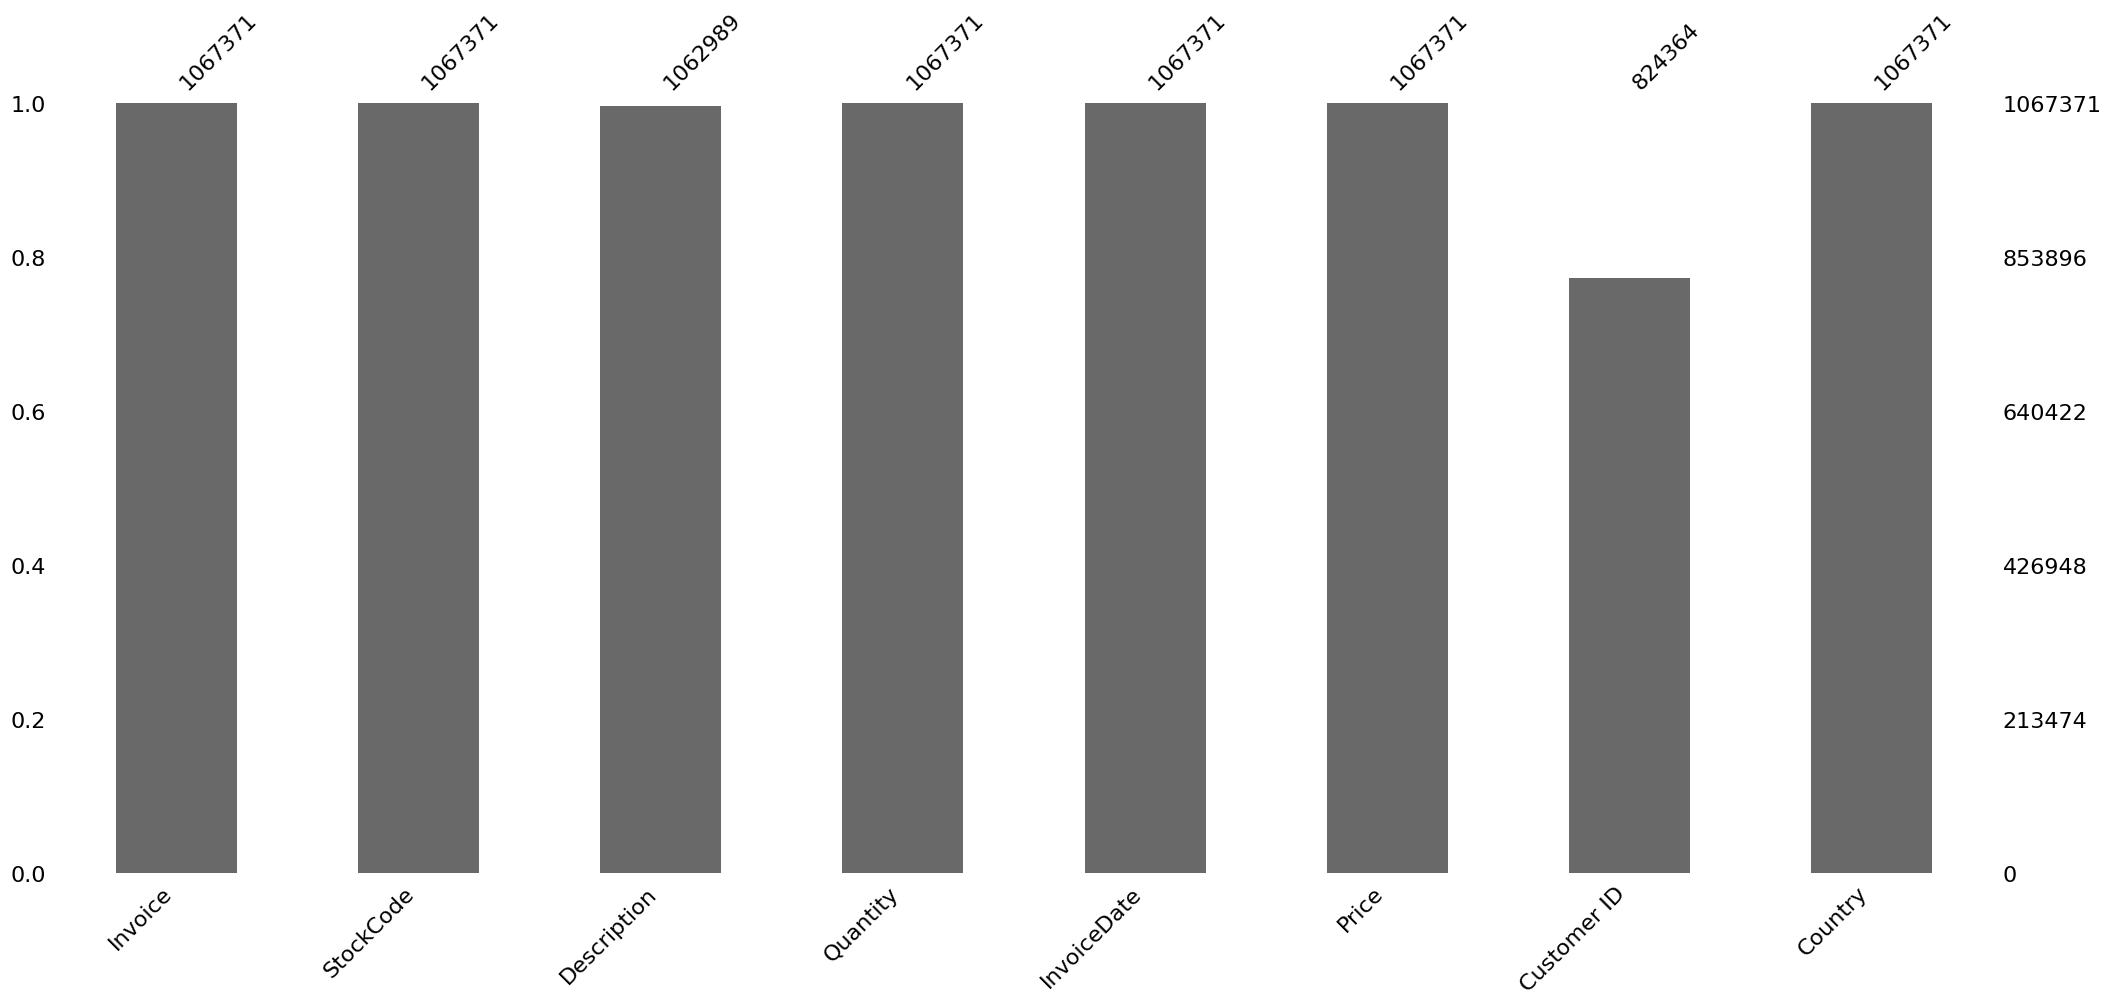

In [8]:
missingno.bar(df)

The `Invoice` column contains values starting with **'C'**, indicating canceled transactions; these will be dropped along with any null values. Additionally, the `StockCode` and `Description` columns are not required for the current analysis and will be set aside until needed.

In [9]:
df = df[~df['Invoice'].str.contains('C', na=False)]
df.drop(["StockCode", "Description"], inplace=True, axis=1)
df.dropna(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805620 non-null  object 
 1   Quantity     805620 non-null  int64  
 2   InvoiceDate  805620 non-null  object 
 3   Price        805620 non-null  float64
 4   Customer ID  805620 non-null  float64
 5   Country      805620 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 43.0+ MB


In [11]:
df.reset_index(drop=True, inplace=True)

In [12]:
df.head()

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
df.shape

(805620, 6)

## 2. RFM (Recency, Frequency, Monetary) Analysis
RFM analysis is a data-driven customer segmentation technique used to evaluate a customer's value based on their past behavior.

* **Recency ($R$)**: Days since the last purchase.
Lower values indicate more engaged customers.

* **Frequency ($F$)**: Total number of purchases. Higher values indicate loyal customers.

* **Monetary ($M$)**: Total revenue generated. Higher values indicate high-spenders.

In [14]:
df['TotalAmount'] = df['Quantity'] * df['Price']
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [15]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [16]:
reference_date = df['InvoiceDate'].max() + timedelta(days=1)

In [17]:
reference_date

Timestamp('2011-12-10 12:50:00')

1.   **Recency**: This is calculated as the number of days between a `reference_date` (the day after the very last transaction in the entire dataset) and the last purchase date (`x.max()`) for each individual customer. A lower number indicates a more recent purchase.

2. **Frequency**: This is determined by counting the total number of invoices (`Invoice`) for each customer, which represents how many distinct purchases they've made.

3. **Monetary**: This sums up the `TotalAmount` spent by each customer, giving their total monetary value.

In [18]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice' : 'count',
    'TotalAmount' : 'sum'
})
rfm = rfm.rename(columns={'InvoiceDate':'Recency', 'Invoice':'Frequency', 'TotalAmount':'Monetary'})
print(rfm.shape)
rfm.head()

(5881, 3)


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,34,77556.46
12347.0,2,253,5633.32
12348.0,75,51,2019.40
12349.0,19,175,4428.69
12350.0,310,17,334.40


### 2.1. RFM Quartile Calculation and Scoring Function

To segment customers based on their behavior, we first calculate the **quartiles (25%, 50%, 75%)** for each RFM metric.

These quartiles are used as thresholds to categorize customers into different levels.

A scoring function is then created to assign scores from **1 to 4**:

- **Recency:** Customers who purchased more recently receive higher scores.
- **Frequency:** Customers who purchase more frequently receive higher scores.
- **Monetary:** Customers who spend more receive higher scores.

This transformation converts raw RFM values into standardized scores that will later be used for **customer segmentation**.

In [19]:
# Quartile Calculation
quartil = rfm.quantile([0.25, 0.5, 0.75])

def score(value, metric_name, quantiles_data):
    if metric_name == 'Recency':
        if value <= quantiles_data[metric_name][0.25]: return 4
        if value <= quantiles_data[metric_name][0.50]: return 3
        if value <= quantiles_data[metric_name][0.75]: return 2
        return 1
    else:
        if value <= quantiles_data[metric_name][0.25]: return 1
        if value <= quantiles_data[metric_name][0.50]: return 2
        if value <= quantiles_data[metric_name][0.75]: return 3
        return 4

### 2.2. Applying RFM Scores

The scoring function is applied to each RFM metric:

- **R (Recency Score):** Measures how recently the customer made a purchase.
- **F (Frequency Score):** Measures how often the customer purchases.
- **M (Monetary Score):** Measures how much the customer spends.

Each customer receives a score between **1 and 4** for each metric based on the previously calculated quartile thresholds.

These scores will be used to evaluate and segment customer behavior.

In [20]:
rfm['R'] = rfm['Recency'].apply(score, args=('Recency', quartil))
rfm['F'] = rfm['Frequency'].apply(score, args=('Frequency', quartil))
rfm['M'] = rfm['Monetary'].apply(score, args=('Monetary', quartil))
rfm.head(5)

,Recency,Frequency,Monetary,R,F,M
Customer ID,,,,,,
12346.0,326,34,77556.46,2,2,4
12347.0,2,253,5633.32,4,4,4
12348.0,75,51,2019.40,3,2,3
12349.0,19,175,4428.69,4,4,4
12350.0,310,17,334.40,2,1,1


### 2.3. Purchases by Country Analysis

To understand the geographical distribution of demand, we calculate the **total quantity of products purchased in each country**.

Steps performed:
- Group transactions by **Country**
- Calculate the **total quantity purchased**
- Sort countries by purchase volume
- Visualize the results using a **bar chart**

This visualization highlights the countries with the highest purchase activity and helps identify the company's most important markets.

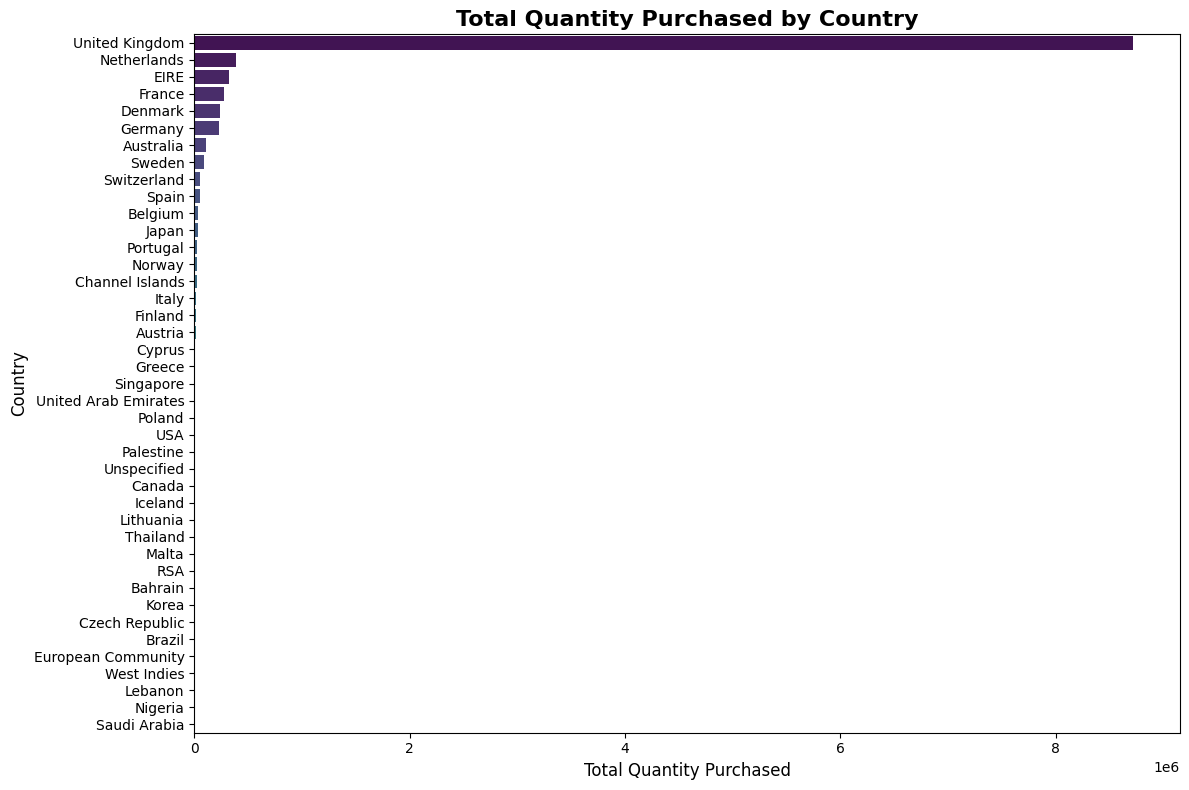

In [21]:
# Calculate total quantity purchased per country from the cleaned 'df' DataFrame
purchases_by_country = df.groupby('Country')['Quantity'].sum().reset_index()

# Rename columns for clarity
purchases_by_country.columns = ['Country', 'purchases_Count']

# Sort for better visualization
purchases_by_country = purchases_by_country.sort_values(by='purchases_Count', ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x='purchases_Count', y='Country', data=purchases_by_country, hue='Country', palette='viridis', legend=False)
plt.title('Total Quantity Purchased by Country', fontsize=16, fontweight='bold')
plt.xlabel('Total Quantity Purchased', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
purchases_by_country.to_csv('purchases_by_country.csv')

### 2.4. Customer Segmentation Based on RFM Score

We classify customers into four segments using K-Means model and RFM Score:

- **(low Recency, high F/M):** Champions
- **(mid Recency, mid F/M):** Loyal
- **(higher Recency, lower F/M):** At Risk
- **(highest Recency, lowest F/M):** Lost

This segmentation provides an easy way to understand customer value and behavior at a glance.

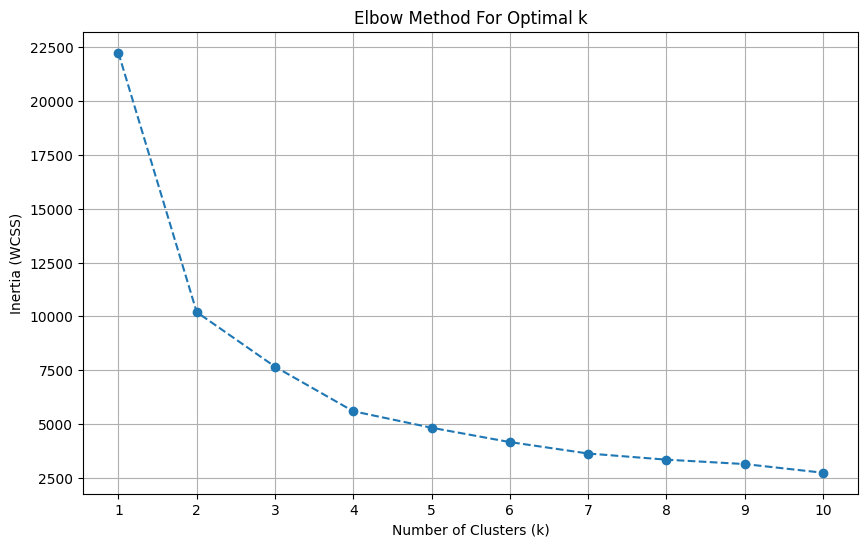

In [23]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)
for k in K_range:
  kmeans = KMeans(n_clusters=k,  init="k-means++", max_iter=300, n_init=10, random_state=0)
  kmeans.fit(rfm[['R', 'F', 'M']])
  inertia.append(kmeans.inertia_)


plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4,  init="k-means++", max_iter=300, n_init=10, random_state=0)
kmeans.fit(rfm[['R', 'F', 'M']])
rfm['Cluster'] = kmeans.labels_

In [25]:
cluster_means = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

rfm['Segment'] = rfm['Cluster'].map({
    0: 'Champions',
    1: 'Loyal',
    2: 'At Risk',
    3: 'Lost'
})
rfm.drop('Cluster', axis=1, inplace=True)
rfm.head()

,Recency,Frequency,Monetary,R,F,M,Segment
Customer ID,,,,,,,
12346.0,326,34,77556.46,2,2,4,Lost
12347.0,2,253,5633.32,4,4,4,Loyal
12348.0,75,51,2019.40,3,2,3,At Risk
12349.0,19,175,4428.69,4,4,4,Loyal
12350.0,310,17,334.40,2,1,1,Champions


In [26]:
import pickle

# Save the KMeans model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

In [27]:
rfm.to_csv('customer_segmentation.csv')
rfm

,Recency,Frequency,Monetary,R,F,M,Segment
Customer ID,,,,,,,
12346.0,326,34,77556.46,2,2,4,Lost
12347.0,2,253,5633.32,4,4,4,Loyal
12348.0,75,51,2019.40,3,2,3,At Risk
12349.0,19,175,4428.69,4,4,4,Loyal
12350.0,310,17,334.40,2,1,1,Champions
...,...,...,...,...,...,...,...
18283.0,4,986,2736.65,4,4,4,Loyal
18284.0,432,28,461.68,1,2,2,Champions
18285.0,661,12,427.00,1,1,2,Champions


### 2.5. Count of Customers by Segment

We calculate the **number of customers in each RFM segment**:

- Provides insight into the distribution of customer value.
- Helps identify how many customers are top performers versus at risk or lost.

In [28]:
rfm['Segment'].value_counts()

,count
Segment,
Champions,1862
Loyal,1591
Lost,1348
At Risk,1080


### 2.6. Percentage of Customers by Segment

We calculate the **proportion of customers in each RFM segment**:

- Shows what percentage of the customer base belongs to each segment.
- Useful for understanding the overall customer distribution.

In [29]:
rfm['Segment'].value_counts(normalize=True) * 100

,proportion
Segment,
Champions,31.661282
Loyal,27.053222
Lost,22.921272
At Risk,18.364224


### 2.7. Visualizing Customer Segments

We create a **bar chart** to display the number of customers in each RFM segment:

- **X-axis:** Customer Segment (Champions, Loyal, At Risk, Lost)  
- **Y-axis:** Total number of customers in each segment  
- **Labels:** Show exact count on each bar

This visualization provides a clear overview of customer distribution across different segments.

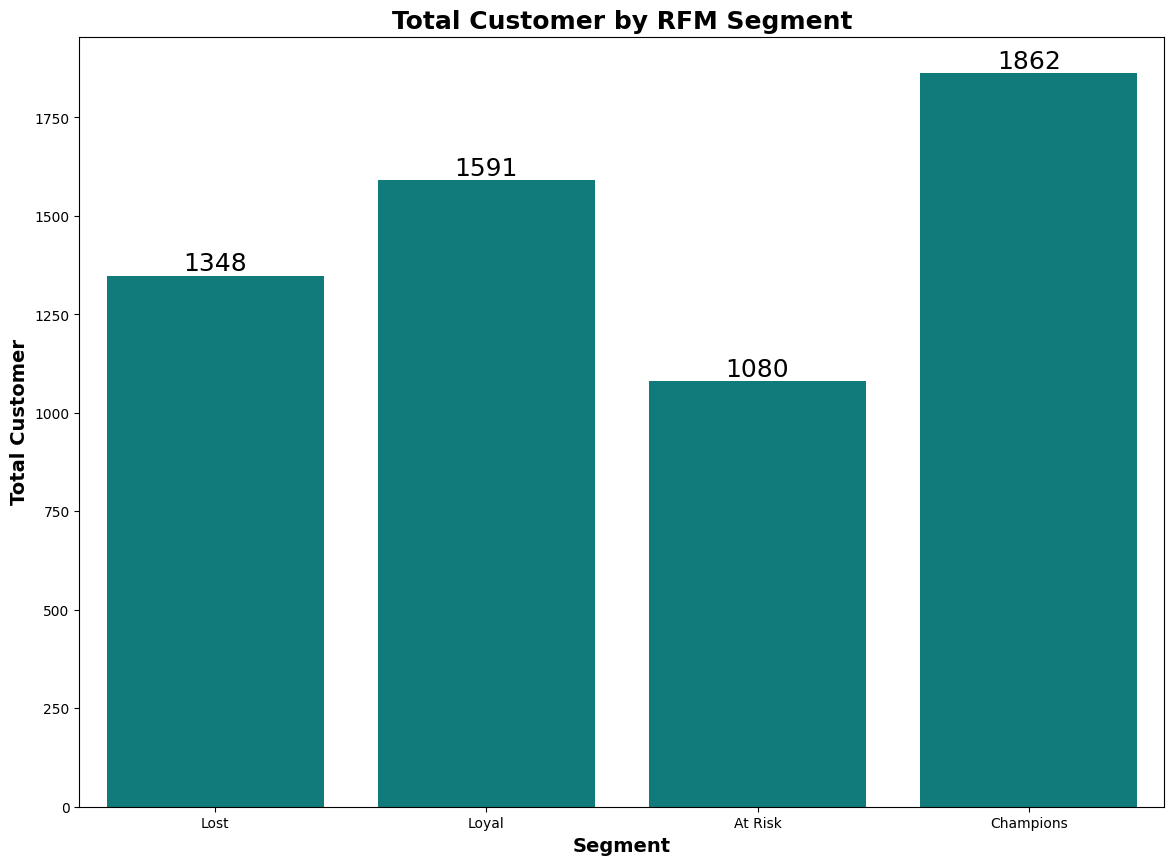

In [30]:
fig, ax = plt.subplots(figsize=(14, 10))
ax = sns.countplot(rfm, x='Segment', color='darkcyan')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=18)
plt.title('Total Customer by RFM Segment', fontsize=18,  weight='bold')
ax.set_xlabel('Segment', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Customer', fontsize=14, fontweight='bold')
plt.show()

## 3. Churn Prediction

### 3.1. Feature Engineering & Labeling
In this section, we transform the raw Recency, Frequency, and Monetary (RFM) metrics and transactional data into a consolidated feature set. This process involves aggregating customer behavior and defining the **Target Variable ($y$)** for the Churn Prediction model.

### 3.2. Feature Extraction
To enhance the model's predictive power, we derive additional behavioral features:

* **Average Quantity (avg_quantity):** Represents the mean volume of items purchased per transaction, serving as an indicator of wholesale vs. retail behavior.

* **Geographic Context (Country):** Captured to account for regional variance in customer retention.

**Churn Definition (Labeling Strategy)**

Since the dataset does not explicitly provide a "churned" status, we employ a statistical thresholding approach based on the Recency distribution.

$$\text{is_churn} = \begin{cases} 1 & \text{if } \text{Recency} > Q_3(\text{Recency}) \\ 0 & \text{otherwise} \end{cases}$$

Where $Q_3$ represents the 75th percentile (the threshold). This assumes that customers in the top 25% of "days since last purchase" are significantly more likely to have attrited.

In [31]:
# 1. Aggregating behavioral features per Customer
avg_quantity = df.groupby('Customer ID')['Quantity'].mean()
country = df.groupby('Customer ID')['Country'].agg('first')

# 2. Defining the Churn Threshold (75th Percentile of Recency)
treshold = rfm['Recency'].quantile(0.75)

# 3. Labeling customers: 1 for Churned, 0 for Retained
is_churn = rfm['Recency'].apply(lambda x: 1 if x > treshold else 0)

# 4. Consolidating into the Final Feature Set
churn = pd.DataFrame({
    'Frequency': rfm['Frequency'],
    'Monetary': rfm['Monetary'],
    'Country': country,
    'avg_quantity': avg_quantity,
    'is_churn': is_churn
})
churn.head()

,Frequency,Monetary,Country,avg_quantity,is_churn
Customer ID,,,,,
12346.0,34,77556.46,United Kingdom,2184.852941,0
12347.0,253,5633.32,Iceland,12.988142,0
12348.0,51,2019.40,Finland,53.215686,0
12349.0,175,4428.69,Italy,9.280000,0
12350.0,17,334.40,Norway,11.588235,0


In [32]:
churn['is_churn'].value_counts()

,count
is_churn,
0,4420
1,1461


To ensure the integrity of the predictive modeling phase, an analysis of the target variable, is_churn, was conducted. The results, as displayed in the frequency distribution, indicate a class imbalance, a common characteristic in behavioral retail datasets.

•	Non-Churn (Class 0): 4,420 observations (~75.16%)

•	Churn (Class 1): 1,461 observations (~24.84%)


In [33]:
churn_no_churn = churn[churn['is_churn'] == 0]
churn_to_drop = churn_no_churn.sample(n=2500, random_state=42)
churn = churn.drop(churn_to_drop.index)
print(churn['is_churn'].value_counts())

is_churn
0    1920
1    1461
Name: count, dtype: int64


In [34]:
churn_model = churn.copy()


### 3.3. One-Hot Encoding (OHE) Strategy
We utilize One-Hot Encoding for the Country feature. This technique creates $n$ binary columns for a feature with $n$ unique categories. Each column represents a category, where a value of 1 indicates presence and 0 indicates absence.

In [35]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
country_encoded = ohe.fit_transform(churn_model[['Country']])
country_df = pd.DataFrame(country_encoded, columns=ohe.get_feature_names_out(['Country']), index=churn_model.index)
churn_model = churn_model.drop('Country', axis=1)
churn_model = pd.concat([churn_model, country_df], axis=1)
churn_model

,Frequency,Monetary,avg_quantity,is_churn,Country_Australia,Country_Austria,Country_Bahrain,Country_Belgium,Country_Brazil,Country_Canada,...,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_Thailand,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified,Country_West Indies
Customer ID,,,,,,,,,,,,,,,,,,,,,
12347.0,253,5633.32,12.988142,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348.0,51,2019.40,53.215686,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12349.0,175,4428.69,9.280000,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12350.0,17,334.40,11.588235,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12351.0,21,300.93,12.428571,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18279.0,13,231.34,48.461538,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18280.0,30,488.15,6.466667,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18284.0,28,461.68,17.642857,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Following the balancing of the dataset, the processed data was partitioned into independent sets for training and evaluation. This Hold-out Validation approach is critical for assessing the model's ability to generalize to unseen data and for detecting potential overfitting.

In [36]:
X = churn_model.drop(['is_churn'], axis=1)
y = churn_model['is_churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23, shuffle =True)

print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (2704, 40)
X_test shape is  (677, 40)
y_train shape is  (2704,)
y_test shape is  (677,)


### 3.4. Model Implementation

In [37]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=500, max_depth=3, learning_rate=0.01, objective='binary:logistic')
xgb_model.fit(X_train, y_train)

y_predXGB = xgb_model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_predXGB)
class_report = classification_report(y_test, y_predXGB)
accuracy = accuracy_score(y_test, y_predXGB)
print(conf_matrix)
print(class_report)
print(accuracy)

[[307  88]
 [ 79 203]]
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       395
           1       0.70      0.72      0.71       282

    accuracy                           0.75       677
   macro avg       0.75      0.75      0.75       677
weighted avg       0.75      0.75      0.75       677

0.7533234859675036


### 3.5. Results and Performance Evaluation
In this section, we evaluate the predictive performance of the XGBoost model. Given the business context of churn prediction, we prioritize metrics that reflect the model's ability to identify at-risk customers over simple global accuracy.


---


**3.5.1. Confusion Matrix Analysis (XGBoost)**

The confusion matrix below illustrates the performance of the current XGBoost implementation on the test set.

| Predicted: No Churn | Predicted: Churn |
|---|---|
| Actual: No Churn 307 (TN) | 88 (FP) |
| Actual: Churn 79 (FN) | 203 (TP) |

**Key Interpretations:**

* **True Negatives (307):** Correctly identified loyal customers.

* **False Positives (88):** "False Alarms" loyal customers incorrectly flagged as churners.

* **False Negatives (79):** "Missed Churn" at-risk customers the model failed to detect.

* **True Positives (203):** Correctly identified customers who actually churned.


---


**3.5.2. Performance Metrics Summary**


| Metric | Value | Academic Assessment |
|---|---|---|
| Accuracy | 0.75 | High overall correctness. |
| Precision (Churn) | 0.70 | 70% of flagged customers actually churned. |
| Recall (Churn) | 0.72 | The model captures 72% of total churners.|
| F1-Score | 0.71 | indicates a high balance between Precision and Recall.|

---


**Conclusion**

In Churn Prediction, **Recall is the primary KPI** because the cost of failing to identify a churned customer (Lost Revenue) far outweighs the cost of a retention campaign (Marketing Expense).

### 3.6. Feature Importance & Model Interpretability
This section evaluates the relative importance of each feature within the XGBoost model's decision-making architecture. By quantifying the average gain across all boosting rounds, we can rank variables according to their predictive significance and contribution to the model's performance.

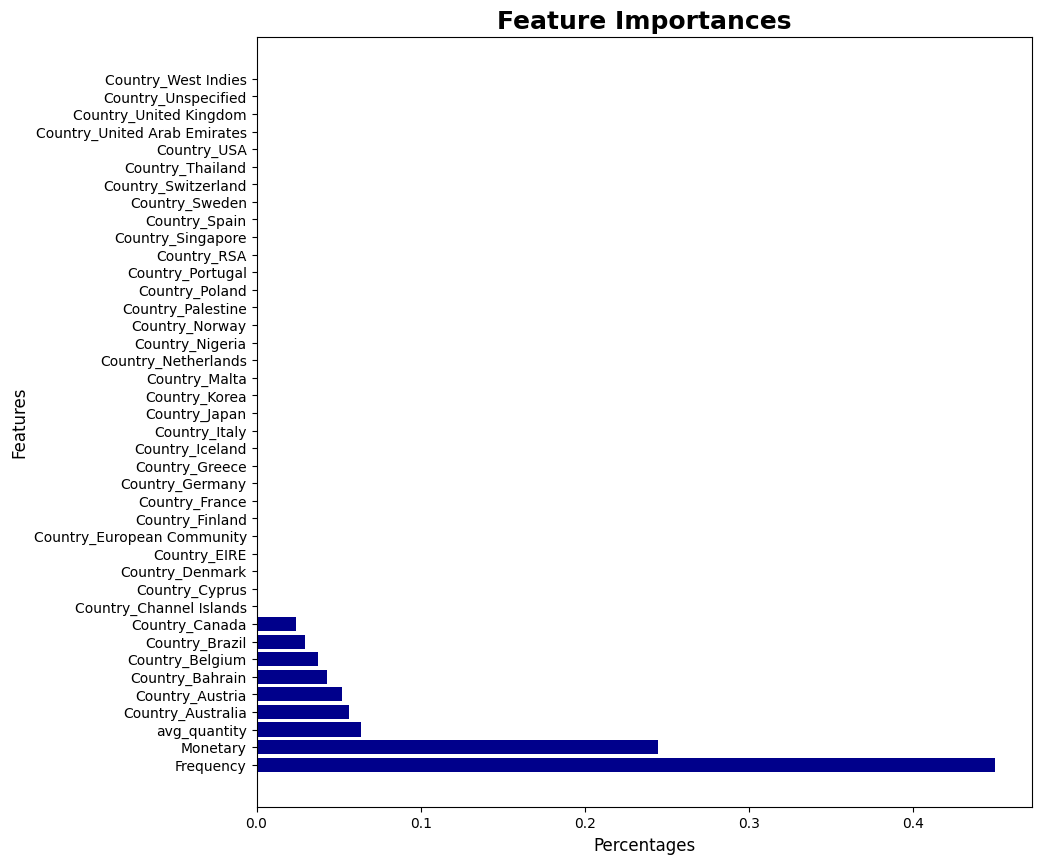

In [38]:
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
names = churn_model.drop(['is_churn'], axis=1).columns

# plot the feature importances
plt.figure(figsize=(10,10))
plt.title('Feature Importances', fontsize=18, fontweight='bold')
plt.barh(range(X.shape[1]), importances[indices], color='darkblue')
plt.yticks(range(X.shape[1]), names)
plt.ylabel('Features', fontsize=12)
plt.xlabel('Percentages', fontsize=12)
plt.show()

### 3.7. Model Inference & Probability Mapping
Upon finalizing the Optimized XGBoost model, the system proceeds to the inference phase, where it generates a continuous probability score for the customer base. In contrast to discrete binary classification—which provides a rigid "Yes/No" label—probability mapping utilizes the model’s logistic output to quantify the likelihood of churn on a scale from 0 to 1.

In [39]:
# assign the churn prediction model to original dataframe by creating new features
y_pred_proba = xgb_model.predict_proba(X.values)
churn_prediction_rate = y_pred_proba[:, 1]
churn['churn_prediction_rate'] = churn_prediction_rate * 100
churn

,Frequency,Monetary,Country,avg_quantity,is_churn,churn_prediction_rate
Customer ID,,,,,,
12347.0,253,5633.32,Iceland,12.988142,0,2.950111
12348.0,51,2019.40,Finland,53.215686,0,33.484257
12349.0,175,4428.69,Italy,9.280000,0,8.450973
12350.0,17,334.40,Norway,11.588235,0,62.725906
12351.0,21,300.93,Unspecified,12.428571,0,59.443665
...,...,...,...,...,...,...
18279.0,13,231.34,United Kingdom,48.461538,1,65.482162
18280.0,30,488.15,United Kingdom,6.466667,0,59.451687
18284.0,28,461.68,United Kingdom,17.642857,1,54.601585


In [40]:
churn.to_csv('churn_prediction.csv')

### 3.8. Macro-Level Predictive Distribution
The final phase of the model evaluation involves analyzing the macro-level distribution of the system's predictions. The following visualization illustrates the ratio of customers classified as "Churn" versus "No Churn" by the Optimized XGBoost model.

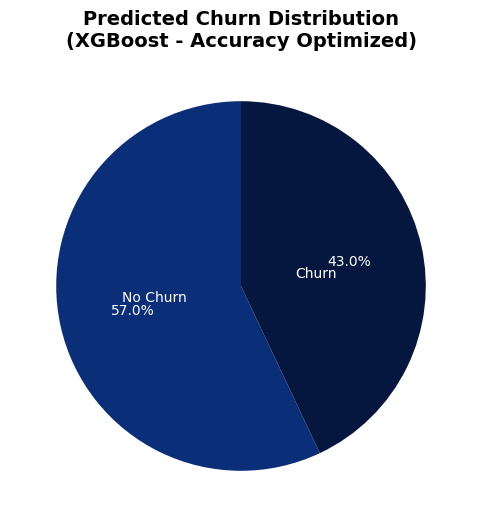

In [41]:
churn_counts_xgb = pd.Series(y_predXGB).value_counts()
labels = ['No Churn', 'Churn']
colors = ['#0B2E79', '#05173E']

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.pie(churn_counts_xgb, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, textprops={'color': 'white'}, labeldistance=0.3)
plt.title('Predicted Churn Distribution\n(XGBoost - Accuracy Optimized)', fontsize=14, fontweight='bold')
plt.show()

### 3.9. Geographic Distribution of Churn Analysis
To further contextualize the predictive results, a granular analysis of churn distribution across different geographical regions was conducted. This step is essential for translating algorithmic outputs into localized business strategies.

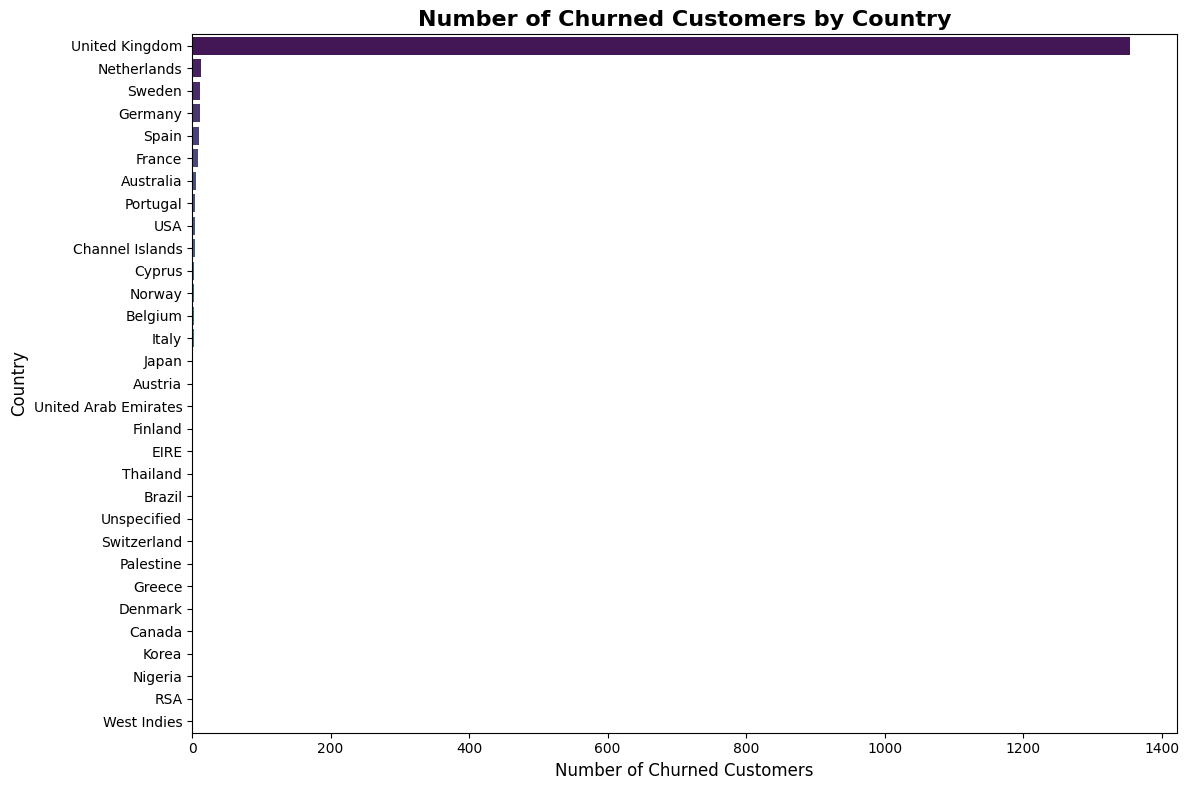

In [42]:
# Filter for churned customers
churned_customers = churn_model[churn_model['is_churn'] == 1]

# Get country columns
country_cols = [col for col in churned_customers.columns if col.startswith('Country_')]

# Sum churns per country
churn_by_country = churned_customers[country_cols].sum().sort_values(ascending=False)

# Prepare data for plotting
churn_by_country_df = churn_by_country.reset_index()
churn_by_country_df.columns = ['Country', 'Churn_Count']
churn_by_country_df['Country'] = churn_by_country_df['Country'].str.replace('Country_', '')

# Filter out countries with 0 churns for cleaner visualization
churn_by_country_df = churn_by_country_df[churn_by_country_df['Churn_Count'] > 0]

# Create the bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Churn_Count', y='Country', data=churn_by_country_df, hue='Country', palette='viridis', legend=False)
plt.title('Number of Churned Customers by Country', fontsize=16, fontweight='bold')
plt.xlabel('Number of Churned Customers', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

In [43]:
churn_by_country_df.to_csv('churn_by_country.csv')

In [44]:
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

## 4. Customer Lifetime Value (CLV) Analysis

We calculate **Customer Lifetime Value (CLV)** to estimate the total value a customer contributes over their lifespan.

This metric helps quantify the **long-term value of each customer** for better strategic decision-making.

**Steps:**

1. **Prepare RFM Data**  
   Copy `Recency`, `Frequency`, and `Monetary` values into a new DataFrame called `clv`.

In [45]:
clv = rfm[['Recency', 'Frequency', 'Monetary']].copy()
clv

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,34,77556.46
12347.0,2,253,5633.32
12348.0,75,51,2019.40
12349.0,19,175,4428.69
12350.0,310,17,334.40
...,...,...,...
18283.0,4,986,2736.65
18284.0,432,28,461.68
18285.0,661,12,427.00


2. **Calculate Customer Age**  
   Determine the number of days between each customer’s first purchase and the latest transaction in the dataset.

In [46]:
max_date = df['InvoiceDate'].max()
clv['Customer_Age'] = df.groupby('Customer ID').agg({'InvoiceDate': lambda x: (max_date-x.min()).days})

3. **Convert Age to Years**  
   Transform customer age from days to years (`Customer_Lifespan_Years`) for more meaningful interpretation.

In [47]:
clv['Customer_Lifespan_Years'] = clv['Customer_Age'] / 365

4. **Compute CLV**  
   Multiply the average monetary value by the customer lifespan in years:

In [48]:
clv['CLV'] = clv['Monetary'] * clv['Customer_Lifespan_Years']

5. **Round Values**  
Round the CLV to 2 decimal places for readability.

In [49]:
clv['CLV'] = clv['CLV'].round(2)

### 4.1. Customer Segmentation by CLV and Churn Risk

We analyze customers based on their **Customer Lifetime Value (CLV)** and **Churn Prediction Rate**.

This combined segmentation helps identify **high-value customers who may be at risk of churn**, which is crucial for targeted retention strategies.

**Steps:**

1. **Add Churn Prediction Rate**  
   Add each customer’s churn probability to the CLV DataFrame.

To provide a comprehensive business overview, a Full-Population Inference was conducted. While training was performed on a balanced subset, the final risk scores were generated for the entire customer database to ensure no high-value segments were excluded from the analysis.

In [50]:
clv['Churn_Prediction_Rate'] = churn['churn_prediction_rate']

2. **Prepare Segmentation DataFrame**  
   Create a copy of the CLV DataFrame (`clv_segment`) for segmentation purposes.

In [51]:
clv_segment = clv.copy()

As we did random undersampling in the churn model, we have to ensure that the data doesn't include any null values.

In [52]:
clv_segment.isna().sum()

,0
Recency,0
Frequency,0
Monetary,0
Customer_Age,0
Customer_Lifespan_Years,0
CLV,0
Churn_Prediction_Rate,2500


The null values exist because we removed 2500 records earlier in the churn model to ensure data balance.

In [53]:
print(f"clv_segment data shape Before removing null values{clv_segment.shape}")
clv_segment.dropna(inplace=True)
print(f"clv_segment data shape after removing null values{clv_segment.shape}")

clv_segment data shape Before removing null values(5881, 7)
clv_segment data shape after removing null values(3381, 7)


The distribution plot below provides a visual confirmation of the Quantile-based binning strategy. By plotting the density of customers against their calculated CLV, we can observe the objective "break points" in the data that define our segmentation tiers.

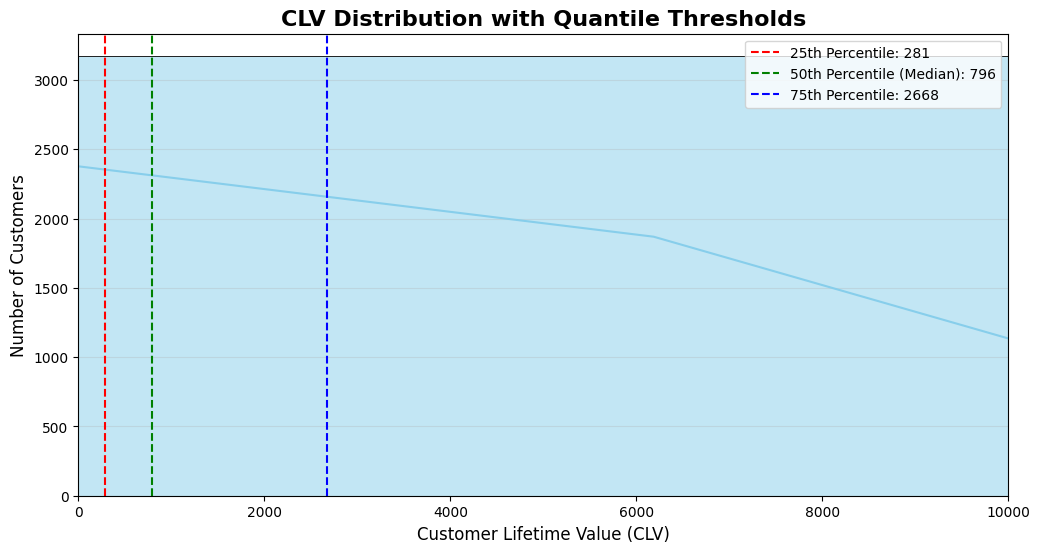

In [54]:
clv_quantiles = clv_segment['CLV'].quantile([0.25, 0.5, 0.75])

plt.figure(figsize=(12, 6))
sns.histplot(clv_segment['CLV'], bins=100, color='skyblue', kde=True)

plt.axvline(clv_quantiles[0.25], color='red', linestyle='--', label=f'25th Percentile: {clv_quantiles[0.25]:.0f}')
plt.axvline(clv_quantiles[0.50], color='green', linestyle='--', label=f'50th Percentile (Median): {clv_quantiles[0.50]:.0f}')
plt.axvline(clv_quantiles[0.75], color='blue', linestyle='--', label=f'75th Percentile: {clv_quantiles[0.75]:.0f}')
plt.title('CLV Distribution with Quantile Thresholds', fontsize=16, fontweight='bold')
plt.xlabel('Customer Lifetime Value (CLV)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend()
plt.xlim(0, 10000)
plt.grid(axis='y', alpha=0.3)
plt.show()

3. **Segment Customers by CLV**  
   Classify customers into four groups based on their CLV:
   - Bronze (CLV ≤ 281)
   - Silver (CLV ≤ 796)
   - Gold (CLV ≤ 2668)
   - Platinum (CLV > 2668)

In [55]:
clv_segment['CLV_segment'] = clv['CLV'].apply(lambda x: 'Bronze' if x <= 281 else 'Silver' if x <= 796 else 'Gold' if x <= 2668 else 'Platinum')

4. **Segment Customers by Churn Risk**  
   Classify customers based on their churn probability:
   - Low Risk (≤ 55%)
   - Medium Risk (≤ 75%)
   - High Risk (> 75%)

In [56]:
clv_segment['Churn_Risk'] = clv['Churn_Prediction_Rate'].apply(lambda x: 'Low Risk' if x <= 55 else 'Medium Risk' if x <= 75 else 'High Risk')

5. **Combine CLV and Churn Risk**  
   Create a new column `Customer_Segment` by combining the CLV segment and churn risk (e.g., Gold-High Risk).

In [57]:
clv_segment['Customer_Segment'] = clv_segment['CLV_segment'] + '-' + clv_segment['Churn_Risk']

In [58]:
clv_segment

,Recency,Frequency,Monetary,Customer_Age,Customer_Lifespan_Years,CLV,Churn_Prediction_Rate,CLV_segment,Churn_Risk,Customer_Segment
Customer ID,,,,,,,,,,
12347.0,2,253,5633.32,403,1.104110,6219.80,2.950111,Platinum,Low Risk,Platinum-Low Risk
12348.0,75,51,2019.40,437,1.197260,2417.75,33.484257,Gold,Low Risk,Gold-Low Risk
12349.0,19,175,4428.69,588,1.610959,7134.44,8.450973,Platinum,Low Risk,Platinum-Low Risk
12350.0,310,17,334.40,309,0.846575,283.09,62.725906,Silver,Medium Risk,Silver-Medium Risk
12351.0,375,21,300.93,374,1.024658,308.35,59.443665,Silver,Medium Risk,Silver-Medium Risk
...,...,...,...,...,...,...,...,...,...,...
18279.0,519,13,231.34,518,1.419178,328.31,65.482162,Silver,Medium Risk,Silver-Medium Risk
18280.0,278,30,488.15,393,1.076712,525.60,59.451687,Silver,Medium Risk,Silver-Medium Risk
18284.0,432,28,461.68,431,1.180822,545.16,54.601585,Silver,Low Risk,Silver-Low Risk


In [59]:
clv_segment.to_csv('clv_segments.csv')

### 4.2. Strategic Segment Analysis: CLV vs. Churn Risk
In this section, we transition from individual predictions to Cohort Analysis. By overlaying Churn Risk onto CLV segments, we categorize the customer base into actionable strategic quadrants. This allows for a prioritized retention strategy where resources are allocated based on the potential financial impact of a customer leaving.

Visualize the count of customer in each CLV segment with churn risk.

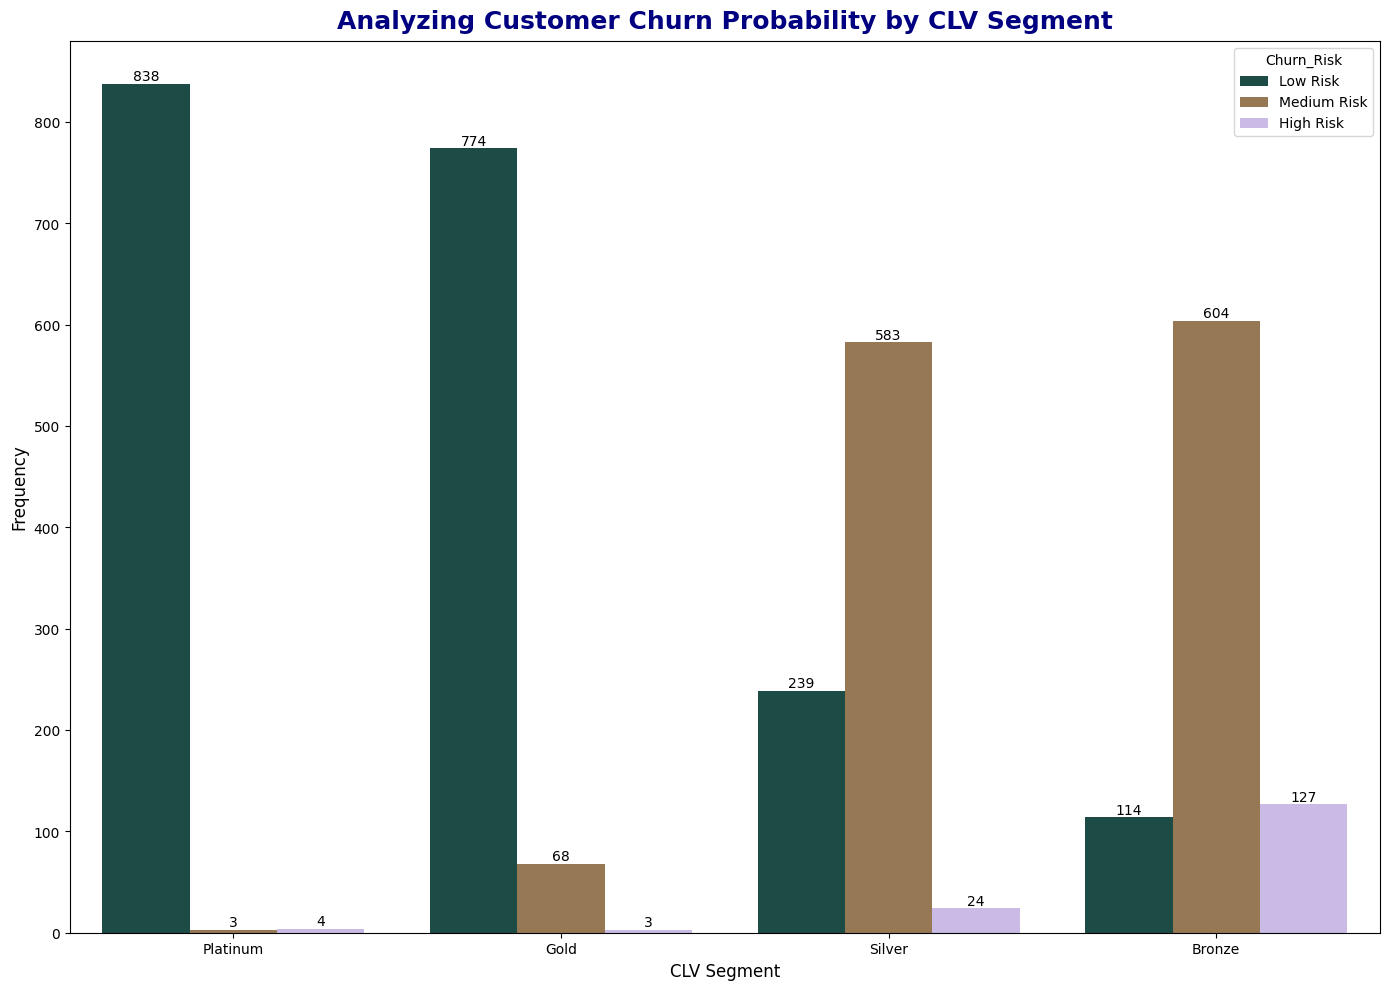

In [60]:
fig, ax = plt.subplots(figsize=(14, 10))
ax = sns.countplot(clv_segment, x='CLV_segment', hue='Churn_Risk', palette='cubehelix')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title('Analyzing Customer Churn Probability by CLV Segment', fontsize=18, fontweight='bold', y=1.005, color='navy')
ax.set_xlabel('CLV Segment', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

### 4.3. Retention Uplift Simulation Function

We define a function `simulate_retention_uplift` to estimate the **revenue increase** if retention improves for a specific segment and risk level.

**Steps performed:**

1. Filter customers by segment and churn risk.
2. Adjust churn probability based on retention improvement percentage.
3. Calculate expected revenue before and after retention improvement.
4. Compute revenue uplift for each customer and total uplift for the segment.

This function provides insights into the **financial impact of retention strategies**.

In [61]:
def simulate_retention_uplift(df, segment, risk_level, retention_increase_percent):
    # Step 1
    segment_mask = clv_segment['CLV_segment'] == f'{segment}-{risk_level}'
    df_result = clv_segment.copy()

    # Step 2
    df_result['Churn_Prob_New'] = df_result.apply(
        lambda row: row['Churn_Prediction_Rate'] * (1 - retention_increase_percent / 100)
        if row['Customer_Segment'] == f"{segment}-{risk_level}"
        else row['Churn_Prediction_Rate'],
        axis=1)

    # Step 3
    df_result['Expected_Revenue_Before'] = df_result['CLV'] * (1- df_result['Churn_Prediction_Rate'])
    df_result['Expected_Revenue_After'] = df_result['CLV'] * (1 - df_result['Churn_Prob_New'])
    df_result['Revenue_Uplift'] = df_result['Expected_Revenue_After'] - df_result['Expected_Revenue_Before']

    # Step 4
    segment_mask = df_result['Customer_Segment'] == f"{segment}-{risk_level}"
    total_uplift = df_result.loc[segment_mask, 'Revenue_Uplift'].sum()

    return {
    'Segment': f'{segment}-{risk_level}',
    'Retention_Increase': retention_increase_percent,
    'Revenue_Uplift': total_uplift
    }

### 4.4. Run Retention Uplift Simulation

We define the target customer segments and retention improvement percentages:

- **Segments:** Platinum-High Risk, Platinum-Medium Risk, Gold-High Risk, Gold-Medium Risk
- **Retention Increase Levels:** 10%, 20%, 30%

We run the simulation for all combinations using `simulate_retention_uplift` and store the results in a DataFrame for analysis.

In [62]:
segments = [
    ('Platinum', 'High Risk'),
    ('Platinum', 'Medium Risk'),
    ('Gold', 'High Risk'),
    ('Gold', 'Medium Risk')
]
retention_increase_levels = [10, 20, 30]

results = []
for segment, risk, in segments:
    for retention_increase in retention_increase_levels:
        result = simulate_retention_uplift(clv_segment, segment, risk, retention_increase)
        results.append(result)

results_df = pd.DataFrame(results)

### 4.5. Format Simulation Results

- Format numbers for readability.
- Convert `Revenue_Uplift` to **millions** for visualization purposes.
- Sort results by segment to prepare for plotting.

In [63]:
pd.set_option('display.float_format', '{:,.2f}'.format)
results_df

,Segment,Retention_Increase,Revenue_Uplift
0,Platinum-High Risk,10,"480,567.98"
1,Platinum-High Risk,20,"961,135.95"
2,Platinum-High Risk,30,"1,441,703.93"
3,Platinum-Medium Risk,10,"184,281.05"
4,Platinum-Medium Risk,20,"368,562.10"
5,Platinum-Medium Risk,30,"552,843.15"
6,Gold-High Risk,10,"45,646.18"
7,Gold-High Risk,20,"91,292.36"
8,Gold-High Risk,30,"136,938.55"
9,Gold-Medium Risk,10,"399,699.56"


In [64]:
results_df['Revenue_Uplift_Million'] = results_df['Revenue_Uplift']/1_000_000
results_df = results_df.sort_values(by='Segment')

### 4.6. Visualize Revenue Uplift by Segment

- **X-axis:** Customer Segment (e.g., Platinum-High Risk)  
- **Y-axis:** Revenue Uplift (Million Euro)  
- **Hue:** Retention increase percentage (10%, 20%, 30%)  
- Add labels on bars for clarity.

This visualization provides insights into which segments benefit most from retention strategies and the potential revenue gains.

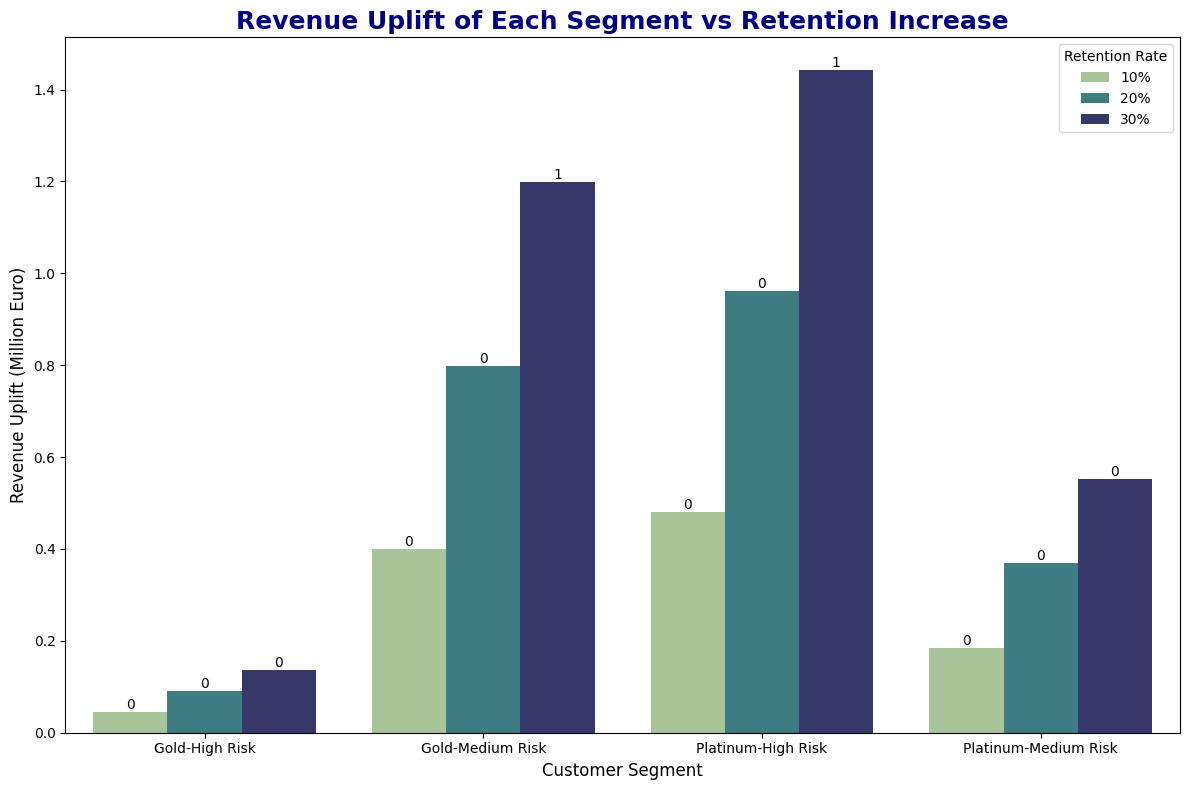

In [65]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(results_df, x='Segment', y='Revenue_Uplift_Million', hue='Retention_Increase', palette='crest')

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

legend = ax.legend(title='Retention Rate')

texts = legend.get_texts()
texts[0].set_text('10%')
texts[1].set_text('20%')
texts[2].set_text('30%')
plt.title('Revenue Uplift of Each Segment vs Retention Increase', fontsize=18, fontweight='bold', color='navy')
ax.set_xlabel('Customer Segment', fontsize=12)
ax.set_ylabel('Revenue Uplift (Million Euro)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()

## 5. Next Purchase Prediction

### 5.1. Temporal Feature Engineering for Next Purchase Prediction
These steps prepare the customer data for predicting their next purchase:

1. **Drop RFM Score Columns:** Remove previous RFM scores as they are not needed for this analysis.

In [66]:
rfm.drop(['R', 'F', 'M', 'Segment'], axis=1, inplace=True)

2. **Calculate Key Dates and Counts:**
   - `last_purchase_date`: The most recent purchase of the customer.
   - `first_purchase_date`: The first purchase of the customer.
   - `total_number_of_purchases`: Count of unique purchases per customer.

In [67]:
rfm['last_purchase_date'] = df.groupby('Customer ID')['InvoiceDate'].max()
rfm['first_purchase_date'] = df.groupby('Customer ID')['InvoiceDate'].min()
rfm['total_number_of_purchases'] = df.groupby('Customer ID')['Invoice'].nunique()

3. **Compute Interpurchase Interval:**
    - Represents the average time between purchases for each customer.
    - Customers with only one purchase are assigned NaN to avoid division by zero.

In [68]:
rfm['Interpurchase Interval'] = (rfm['last_purchase_date'] - rfm['first_purchase_date']) / (rfm['total_number_of_purchases'] - 1)

# Calculate the difference between last and first purchase dates, resulting in Timedelta objects
time_diff = rfm['last_purchase_date'] - rfm['first_purchase_date']

# Convert Timedelta to days (as floats to handle NaN)
time_diff_days = time_diff.dt.days

# Avoid division by zero for customers with only one purchase (total_number_of_purchases == 1)
# For these, Interpurchase Interval is undefined, so set to NaN
denominator = rfm['total_number_of_purchases'] - 1
rfm['Interpurchase Interval'] = np.where(denominator == 0, np.nan, time_diff_days / denominator)

4. **Clean Data:**
    - Remove rows with missing values.
    - Filter out intervals less than 2 days to remove unrealistic values.

In [69]:
rfm.dropna(inplace=True)
rfm = rfm[rfm['Interpurchase Interval'] >= 2]
rfm

,Recency,Frequency,Monetary,last_purchase_date,first_purchase_date,total_number_of_purchases,Interpurchase Interval
Customer ID,,,,,,,
"12,346.00",326,34,"77,556.46",2011-01-18 10:01:00,2009-12-14 08:34:00,12,36.36
"12,347.00",2,253,"5,633.32",2011-12-07 15:52:00,2010-10-31 14:20:00,8,57.43
"12,348.00",75,51,"2,019.40",2011-09-25 13:13:00,2010-09-27 14:59:00,5,90.50
"12,349.00",19,175,"4,428.69",2011-11-21 09:51:00,2010-04-29 13:20:00,4,190.00
"12,352.00",36,103,"2,849.84",2011-11-03 14:37:00,2010-11-12 10:20:00,10,39.56
...,...,...,...,...,...,...,...
"18,281.00",181,17,201.14,2011-06-12 10:53:00,2010-05-11 10:49:00,2,397.00
"18,282.00",8,12,178.05,2011-12-02 11:43:00,2011-08-05 13:35:00,2,118.00
"18,283.00",4,986,"2,736.65",2011-12-06 12:02:00,2010-02-19 17:16:00,22,31.14


### 5.2. Calculate Standard Deviation of Interpurchase Intervals

- Create a copy of the RFM DataFrame to avoid modifying original data.

- Compute the difference in days between consecutive purchases for each customer.
- Calculate the standard deviation of these interpurchase intervals.
- Add `Interpurchase_Interval_Std` as a new feature in the dataset to represent variability in customer purchase behavior.

In [70]:
next_purchase_df = rfm.copy()

time_diffs = df.groupby('Customer ID')['InvoiceDate'].apply(lambda x: x.sort_values().diff().dt.days)
interpurchase_std = time_diffs.groupby('Customer ID').std().rename('Interpurchase_Interval_Std')
next_purchase_df = next_purchase_df.merge(interpurchase_std.to_frame(), left_index=True, right_index=True, how='left')

next_purchase_df.head()

,Recency,Frequency,Monetary,last_purchase_date,first_purchase_date,total_number_of_purchases,Interpurchase Interval,Interpurchase_Interval_Std
Customer ID,,,,,,,,
"12,346.00",326,34,"77,556.46",2011-01-18 10:01:00,2009-12-14 08:34:00,12,36.36,40.41
"12,347.00",2,253,"5,633.32",2011-12-07 15:52:00,2010-10-31 14:20:00,8,57.43,9.84
"12,348.00",75,51,"2,019.40",2011-09-25 13:13:00,2010-09-27 14:59:00,5,90.50,28.62
"12,349.00",19,175,"4,428.69",2011-11-21 09:51:00,2010-04-29 13:20:00,4,190.00,31.90
"12,352.00",36,103,"2,849.84",2011-11-03 14:37:00,2010-11-12 10:20:00,10,39.56,19.84


### 5.3. Recent Purchases Feature Engineering

- For each customer, calculate the number of purchases in the last 30, 60, and 90 days.
- These features (`Purchases_Last_30_Days`, `Purchases_Last_60_Days`, `Purchases_Last_90_Days`) capture recent customer activity to improve next purchase prediction.

In [71]:
overall_latest_date = df['InvoiceDate'].max()

def get_purchases_in_period(customer_id, days):
    customer_df = df[df['Customer ID'] == customer_id]
    start_date = overall_latest_date - timedelta(days=days)
    recent_purchases = customer_df[(customer_df['InvoiceDate'] > start_date) & (customer_df['InvoiceDate'] <= overall_latest_date)]
    return recent_purchases['Invoice'].nunique()

next_purchase_df['Purchases_Last_30_Days'] = next_purchase_df.index.to_series().apply(lambda x: get_purchases_in_period(x, 30))
next_purchase_df['Purchases_Last_60_Days'] = next_purchase_df.index.to_series().apply(lambda x: get_purchases_in_period(x, 60))
next_purchase_df['Purchases_Last_90_Days'] = next_purchase_df.index.to_series().apply(lambda x: get_purchases_in_period(x, 90))

next_purchase_df.head()

,Recency,Frequency,Monetary,last_purchase_date,first_purchase_date,total_number_of_purchases,Interpurchase Interval,Interpurchase_Interval_Std,Purchases_Last_30_Days,Purchases_Last_60_Days,Purchases_Last_90_Days
Customer ID,,,,,,,,,,,
"12,346.00",326,34,"77,556.46",2011-01-18 10:01:00,2009-12-14 08:34:00,12,36.36,40.41,0,0,0
"12,347.00",2,253,"5,633.32",2011-12-07 15:52:00,2010-10-31 14:20:00,8,57.43,9.84,1,2,2
"12,348.00",75,51,"2,019.40",2011-09-25 13:13:00,2010-09-27 14:59:00,5,90.50,28.62,0,0,1
"12,349.00",19,175,"4,428.69",2011-11-21 09:51:00,2010-04-29 13:20:00,4,190.00,31.90,1,1,1
"12,352.00",36,103,"2,849.84",2011-11-03 14:37:00,2010-11-12 10:20:00,10,39.56,19.84,0,1,3


### 5.4. Prepare Training and Testing Sets for Next Purchase Prediction

- Assign feature set `X` to include new engineered features.
- Round target variable `y` (`Interpurchase Interval`) to integer days.
- Split the dataset into training and testing sets (80% train, 20% test) using `train_test_split`.
- Display the shapes of X_train, X_test, y_train, and y_test to confirm dataset preparation.

In [72]:
X = next_purchase_df.drop(['Interpurchase Interval', 'last_purchase_date', 'first_purchase_date'], axis=1)
y = next_purchase_df['Interpurchase Interval'].round()
display(X.head(), y.head())

X_train_npd, X_test_npd, y_train_npd, y_test_npd = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print('X_train_npd shape is', X_train_npd.shape)
print('X_test_npd shape is', X_test_npd.shape)
print('y_train_npd shape is', y_train_npd.shape)
print('y_test_npd shape is', y_test_npd.shape)

,Recency,Frequency,Monetary,total_number_of_purchases,Interpurchase_Interval_Std,Purchases_Last_30_Days,Purchases_Last_60_Days,Purchases_Last_90_Days
Customer ID,,,,,,,,
"12,346.00",326,34,"77,556.46",12,40.41,0,0,0
"12,347.00",2,253,"5,633.32",8,9.84,1,2,2
"12,348.00",75,51,"2,019.40",5,28.62,0,0,1
"12,349.00",19,175,"4,428.69",4,31.90,1,1,1
"12,352.00",36,103,"2,849.84",10,19.84,0,1,3


,Interpurchase Interval
Customer ID,
"12,346.00",36.00
"12,347.00",57.00
"12,348.00",90.00
"12,349.00",190.00
"12,352.00",40.00


X_train_npd shape is (3337, 8)
X_test_npd shape is (835, 8)
y_train_npd shape is (3337,)
y_test_npd shape is (835,)


### 5.5. Train Random Forest Regressor Model for Next Purchase Prediction

- Initialize `RandomForestRegressor` with 100 trees and a fixed random state for reproducibility.
- Train the model on the training dataset (`X_train_npd`, `y_train_npd`).


In [73]:
npd_model = RandomForestRegressor(n_estimators=100, random_state=42)
npd_model.fit(X_train_npd, y_train_npd)

RandomForestRegressor(random_state=42)

### 5.6. Evaluate Next Purchase Prediction Model

- Make predictions on the test set `X_test_npd`.
- Compute model performance metrics:
  - Mean Absolute Error (MAE)
  - R-squared (R²)
- Plot a scatter plot of **Actual vs Predicted Interpurchase Interval** for visual assessment.

In [74]:
y_pred_npd = npd_model.predict(X_test_npd)

mae = mean_absolute_error(y_test_npd, y_pred_npd)
r2 = r2_score(y_test_npd, y_pred_npd)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'R-squared (R2): {r2:.2f}')

Mean Absolute Error (MAE): 11.80
R-squared (R2): 0.94


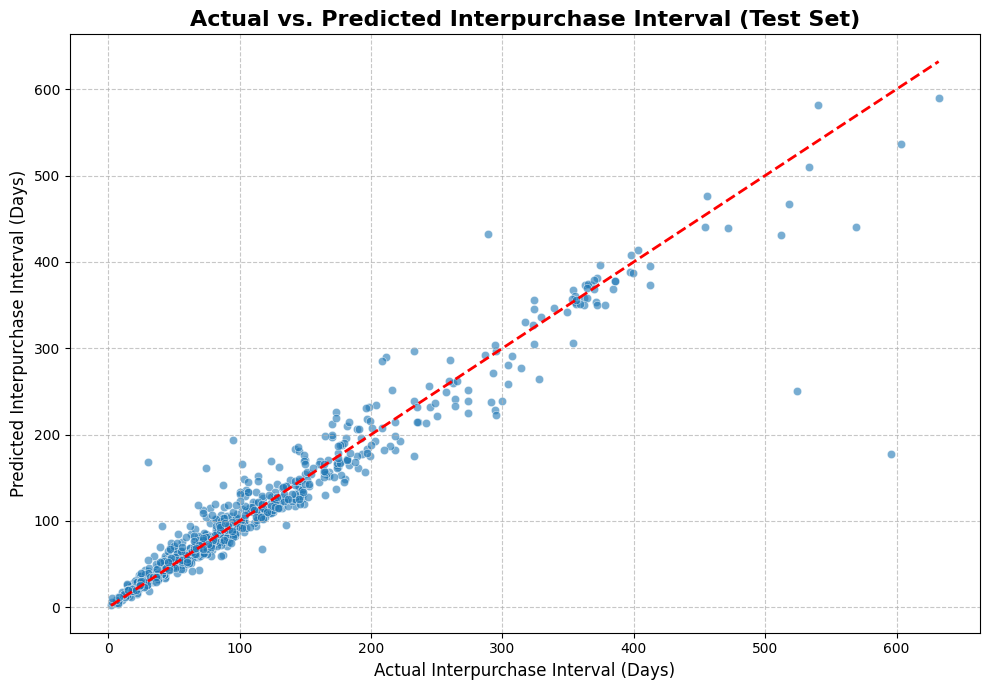

In [75]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_npd, y=y_pred_npd, alpha=0.6)
plt.plot([y_test_npd.min(), y_test_npd.max()], [y_test_npd.min(), y_test_npd.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Interpurchase Interval (Test Set)', fontsize=16, fontweight='bold')
plt.xlabel('Actual Interpurchase Interval (Days)', fontsize=12)
plt.ylabel('Predicted Interpurchase Interval (Days)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [76]:
npd = X_test_npd.copy()
npd['labels'] = y_test_npd
npd['predictions'] = y_pred_npd
npd.to_csv('next_purchase_data.csv')
npd

,Recency,Frequency,Monetary,total_number_of_purchases,Interpurchase_Interval_Std,Purchases_Last_30_Days,Purchases_Last_60_Days,Purchases_Last_90_Days,labels,predictions
Customer ID,,,,,,,,,,
"14,399.00",394,193,"2,113.16",8,8.54,0,0,0,40.00,38.38
"15,551.00",37,151,"1,710.08",7,30.48,0,1,1,86.00,107.25
"13,421.00",40,272,"4,103.12",8,19.13,0,1,1,89.00,91.87
"13,134.00",86,121,"2,475.23",6,17.67,0,0,1,66.00,78.14
"15,827.00",73,231,"3,794.07",28,10.14,0,0,1,23.00,25.27
...,...,...,...,...,...,...,...,...,...,...
"15,471.00",2,162,"1,316.56",3,32.52,1,1,1,274.00,239.11
"17,853.00",407,106,"1,608.19",3,26.09,0,0,0,164.00,165.65
"15,033.00",5,510,"2,586.67",10,5.42,2,4,4,36.00,28.90


### 5.7. Feature Importance for Next Purchase Prediction

- Extract feature importances from the trained `RandomForestRegressor`.
- Sort features in descending order of importance.
- Visualize the feature importances using a bar chart.
- Helps understand which customer attributes most influence the next purchase interval.

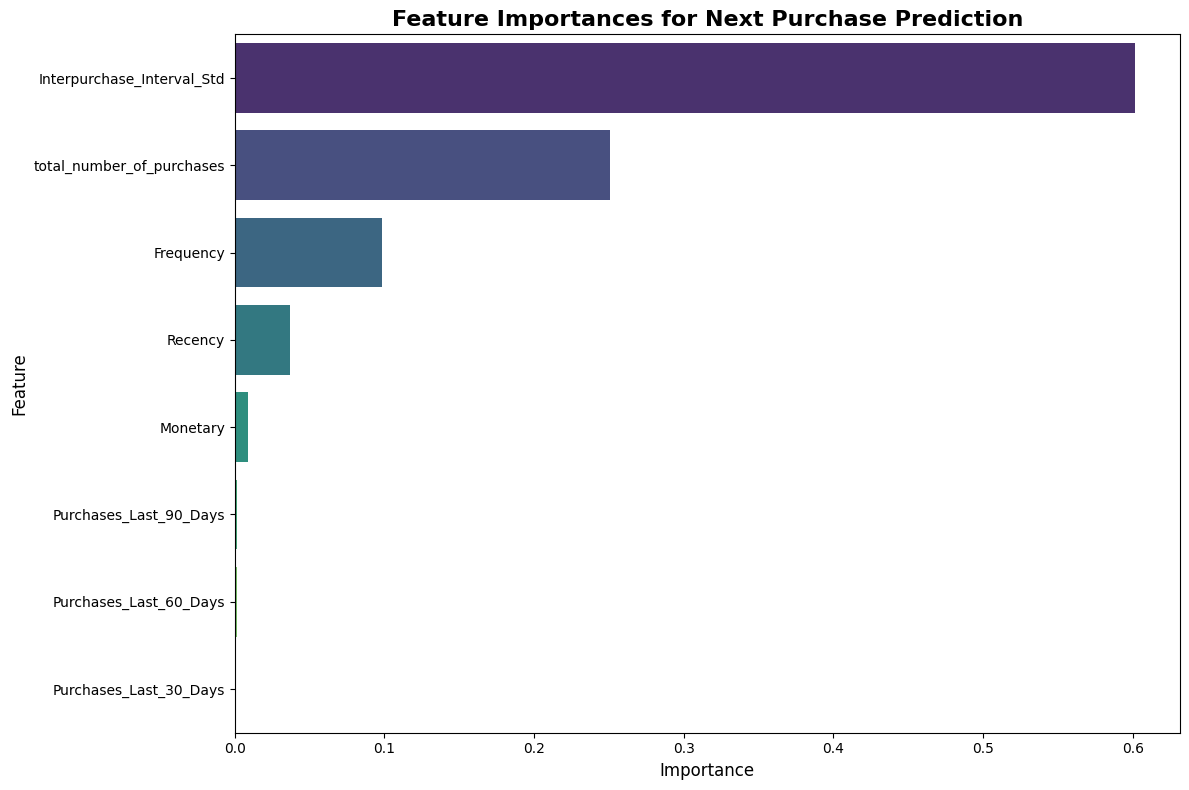

In [77]:
importances_npd = npd_model.feature_importances_
feature_names_npd = X_train_npd.columns

feature_importance_df_npd = pd.DataFrame({
    'Feature': feature_names_npd,
    'Importance': importances_npd
})

feature_importance_df_npd = feature_importance_df_npd.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_npd, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importances for Next Purchase Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [78]:
with open('npd_model.pkl', 'wb') as f:
    pickle.dump(npd_model, f)